In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Read rwa_lr_training.csv
root_dir = "/Users/michaeldoherty/git/XLRON/data/JOCN_SI/rwa_lr"
training_data = pd.read_csv(f"{root_dir}/rwa_lr_training.csv")
training_data_std = pd.read_csv(f"{root_dir}/rwalr_training_std.csv")
## N.B. WE NEED TO UPSAMPLE THE DATA BECAUSE DATA WAS DOWNSAMPLED BY 100 FOR LOGGING PURPOSES DURING TRAINING)
## THEN, we multiply by 5 because only logged every fifth episode due to the scale factor
# Method 1: Simple replication
# This will just repeat each row 100 times
def upsample(df):
    df_upsampled = df.loc[df.index.repeat(5)].reset_index(drop=True)
    
    # Method 2: Linear interpolation
    # This creates a smoother transition between values
    df_upsampled = pd.DataFrame(index=range(1000))
    for column in df.columns:
        df_upsampled[column] = np.interp(
            np.linspace(0, len(df)-1, 1000),
            range(len(df)),
            df[column]
        )
    return df_upsampled
training_data = upsample(training_data)
training_data_std = upsample(training_data_std)
episode_returns = training_data["RWA_LIGHTPATH_REUSE_NSFNET_100_GNN_INC - episode_returns_mean"]
episode_returns_std = training_data_std["RWA_LIGHTPATH_REUSE_NSFNET_100_GNN_INC - episode_returns_std"]
accepted_services = 2000-(2000-episode_returns)/2
accepted_services_std = (np.sum(episode_returns_std**2)/len(episode_returns_std))**0.5
kspff_episode_returns = pd.read_csv(f"{root_dir}/rwa_lr_kspff.csv")
kspff_episode_returns = kspff_episode_returns["RWA_LIGHTPATH_REUSE_NSFNET_100_GNN_INC_ksp_ff - episode_returns_mean"]
kspff_accepted_services = 2000-(2000-kspff_episode_returns)/2
kspff_mean = kspff_accepted_services.mean()
kspff_std = kspff_accepted_services.std()
training_data

,Step,RWA_LIGHTPATH_REUSE_NSFNET_100_GNN_INC - episode_returns_mean,RWA_LIGHTPATH_REUSE_NSFNET_100_GNN_INC - episode_returns_mean__MIN,RWA_LIGHTPATH_REUSE_NSFNET_100_GNN_INC - episode_returns_mean__MAX
0,0.000000,0.000000,0.000000,0.000000
1,20.018018,59.419998,59.419998,59.419998
2,40.036036,21.000000,21.000000,21.000000
3,60.054054,-0.180000,-0.180000,-0.180000
4,80.072072,4.599999,4.599999,4.599999
...,...,...,...,...
995,19917.927928,338.459991,338.459991,338.459991
996,19937.945946,336.199982,336.199982,336.199982
997,19957.963964,335.119995,335.119995,335.119995
998,19977.981982,341.160004,341.160004,341.160004


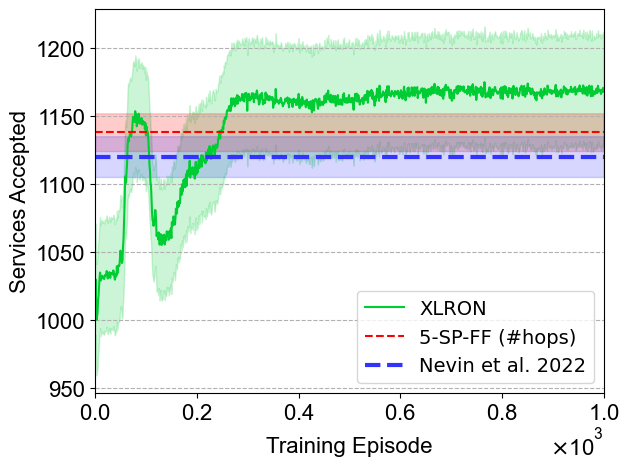

In [3]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Define the font properties
font_props = fm.FontProperties(family='Arial', size=16)
number_props = fm.FontProperties(family='Arial', size=16)

# Define colors
nevin_color = "#3333FF"
kspff_color = "red"
xlron_color = "#00CC33"

# Create figure and axes
fig = plt.figure()
ax = fig.add_subplot(111)

# Plot on the axes object
ax.plot(accepted_services, color=xlron_color, label="XLRON")
ax.fill_between(range(len(accepted_services)), accepted_services-accepted_services_std, accepted_services+accepted_services_std, color=xlron_color, alpha=0.2)
ax.axhline(y=kspff_mean, color=kspff_color, linestyle='--', label='5-SP-FF (#hops)')
ax.fill_between(range(len(accepted_services)), kspff_mean-kspff_std, kspff_mean+kspff_std, color=kspff_color, alpha=0.2)
ax.axhline(y=1120, linestyle='--', label='Nevin et al. 2022', color=nevin_color, linewidth=3)
ax.fill_between(range(len(accepted_services)), 1120-15, 1120+15, color=nevin_color, alpha=0.2)

# Set labels with font properties
ax.set_xlabel('Training Episode', fontproperties=font_props, labelpad=10)
ax.set_ylabel('Services Accepted', fontproperties=font_props)

# Set axis limits and other properties
ax.set_xlim(0, 1000)
ax.legend(loc='lower right', fontsize=14)
ax.grid(axis='y', linestyle='--')

# Format x-axis to scientific notation
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0,0))
ax.xaxis.set_major_formatter(formatter)

# Apply font properties to tick labels
for label in ax.get_xticklabels():
    label.set_fontproperties(font_props)
for label in ax.get_yticklabels():
    label.set_fontproperties(number_props)

# Make the scientific notation offset text match the font properties
ax.xaxis.get_offset_text().set_fontproperties(font_props)

# Adjust layout and save (these are figure-level operations)
fig.tight_layout()
fig.savefig("rwalr_training.png")

In [53]:
# Do boxplot of points 15000-20000 
accepted_services_final = accepted_services[15000:20000]
kspff_accepted_services_final = kspff_accepted_services[1500:2000]
plt.boxplot([accepted_services_final, kspff_accepted_services_final], labels=["XLRON", "KSP-FF"], sym="", positions=[0.1,0.5])
plt.ylabel("Services Accepted", fontsize=14)

In [67]:
plt.rc('xtick', labelsize=12)    # fontsize of the tick labels
plt.rc('ytick', labelsize=12) 
fig = plt.figure()
xlabels = ["CG", "EG"]
ax = fig.add_subplot(111)
ax.boxplot([accepted_services_final, kspff_accepted_services_final], sym="", positions=[0.1,0.5])
ax.set_xticklabels(["XLRON", "KSP-FF"], fontsize=14)
plt.ylabel("Services Accepted", fontsize=14)